In [1]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# stile grafici
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

PLOTS_DIR = os.path.join("results", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

In [3]:
# trova tutti i CSV di simulazione
files = glob.glob(os.path.join("results", "sim_*.csv"))
if not files:
    raise FileNotFoundError("Nessun file sim_*.csv trovato in results/.")

latest = max(files, key=os.path.getmtime)
print("Userò il file:", latest)

df = pd.read_csv(latest)
df.head()

Userò il file: results\sim_20260508_114100.csv


,agent_id,age,age_group,role,crypto_experience,security_training,environment,message_id,message_type,channel,scenario_description,urgency,personalization,reward,choice,motivation
0,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,exchange_kyc_urgente,phishing,email,Finta mail dell'exchange che minaccia blocco c...,alta,bassa,nessuno,CLICCA_SUL_LINK,"Non penso che sia un problema, è probabilmente..."
1,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,defi_airdrop_premio,phishing,social,Airdrop DeFi con APY molto elevati,media,bassa,altissimo,CLICCA_SUL_LINK,"Sono un teenager e mi piace il sociale, mi sem..."
2,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,supporto_tecnico_seed,phishing,chat,Finto supporto tecnico che chiede seed phrase,alta,media,nessuno,5,Il messaggio sembra troppo 'off' per essere ge...
3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,discord_moderatore_rugpull,phishing,chat,Finto moderatore Discord che invia link a dApp...,bassa,alta,alta,CLICCA_SUL_LINK,Sono attirato dalla promessa di un bonus del 5...
4,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,twitter_giveaway_match,phishing,social,"Giveaway su social con schema 'inviami 1 ETH, ...",alta,bassa,altissimo,CLICK_SUL_LINK,Sono un grande fan di CryptoInfluencerXYZ e no...


In [4]:
df.shape

(720, 16)

In [5]:
# normalizza choice
df["choice"] = df["choice"].astype(str).str.strip().str.upper()

print("Valori unici di choice (prima della mappatura):")
print(df["choice"].value_counts())


Valori unici di choice (prima della mappatura):
choice
CLICCA_SUL_LINK              329
5                            125
SEGNALA_COME_PHISHING         99
IGNORA                        52
1) IGNORA                     26
CLICK_SUL_LINK                25
2) CLICCA_SUL_LINK            17
2                             16
5) SEGNALA_COME_PHISHING      16
CHIEDI_AIUTO_AMICO             7
INSERISCI_CREDENZIALI          4
5) SEGNALA_COMME_PHISHING      2
4                              1
CLICKA_SUL_LINK                1
Name: count, dtype: int64


In [6]:
# mappa tutte le varianti nelle 5 categorie pulite
mapping = {
    "1) IGNORA": "IGNORA",
    "1": "IGNORA",

    "2) CLICCA_SUL_LINK": "CLICCA_SUL_LINK",
    "2": "CLICCA_SUL_LINK",
    "CLICK_SUL_LINK": "CLICCA_SUL_LINK",
    "CLICKA_SUL_LINK": "CLICCA_SUL_LINK",

    "4": "CHIEDI_AIUTO_AMICO",

    "5": "SEGNALA_COME_PHISHING",
    "5) SEGNALA_COME_PHISHING": "SEGNALA_COME_PHISHING",
    "5) SEGNALA_COMME_PHISHING": "SEGNALA_COME_PHISHING"
}

df["choice"] = df["choice"].replace(mapping)

print("Valori unici di choice (dopo la mappatura):")
print(df["choice"].value_counts())

Valori unici di choice (dopo la mappatura):
choice
CLICCA_SUL_LINK          388
SEGNALA_COME_PHISHING    242
IGNORA                    78
CHIEDI_AIUTO_AMICO         8
INSERISCI_CREDENZIALI      4
Name: count, dtype: int64


In [7]:
choice_counts = df["choice"].value_counts().sort_index()
choice_perc = (choice_counts / len(df) * 100).round(2)

print("Conteggi assoluti:")
print(choice_counts)
print("\nPercentuali (%):")
print(choice_perc)

Conteggi assoluti:
choice
CHIEDI_AIUTO_AMICO         8
CLICCA_SUL_LINK          388
IGNORA                    78
INSERISCI_CREDENZIALI      4
SEGNALA_COME_PHISHING    242
Name: count, dtype: int64

Percentuali (%):
choice
CHIEDI_AIUTO_AMICO        1.11
CLICCA_SUL_LINK          53.89
IGNORA                   10.83
INSERISCI_CREDENZIALI     0.56
SEGNALA_COME_PHISHING    33.61
Name: count, dtype: float64


'results\\plots\\global_choice_distribution.png'

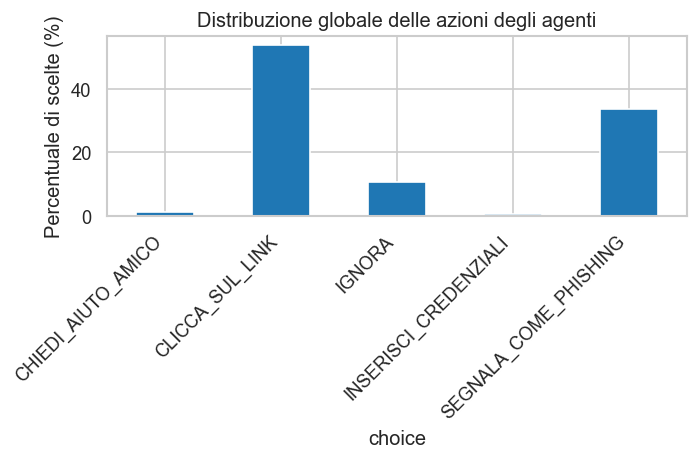

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
choice_perc.plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_ylabel("Percentuale di scelte (%)")
ax.set_title("Distribuzione globale delle azioni degli agenti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "global_choice_distribution.png")
fig.savefig(plot_path, dpi=300)
plot_path

In [9]:
crosstab_type = pd.crosstab(
    df["message_type"],
    df["choice"],
    normalize="index"
).round(3)

crosstab_type

choice,CHIEDI_AIUTO_AMICO,CLICCA_SUL_LINK,IGNORA,INSERISCI_CREDENZIALI,SEGNALA_COME_PHISHING
message_type,,,,,
legitimo,0.000,0.622,0.200,0.000,0.178
phishing,0.015,0.511,0.078,0.007,0.389


'results\\plots\\choices_by_message_type.png'

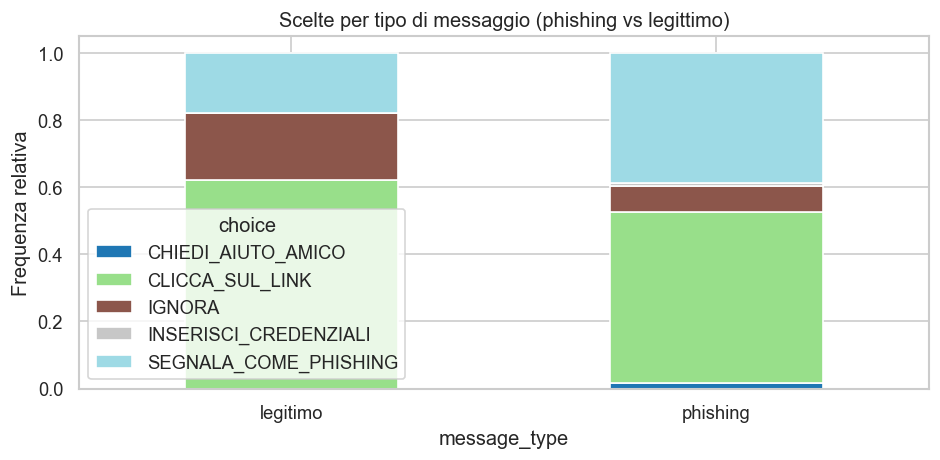

In [10]:
fig, ax = plt.subplots(figsize=(8,4))

crosstab_type.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20"
)

ax.set_ylabel("Frequenza relativa")
ax.set_title("Scelte per tipo di messaggio (phishing vs legittimo)")
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "choices_by_message_type.png")
fig.savefig(plot_path, dpi=300)
plot_path

In [11]:
training_map = {
    "no": "nessuna",
    "minima": "nessuna",
    "basilare": "base",
    "autodidatta": "base",
    "si": "avanzata"
}

df["training_level"] = df["security_training"].map(training_map).fillna(df["security_training"])

print(df["training_level"].value_counts())

training_level
nessuna     288
base        240
avanzata    192
Name: count, dtype: int64


In [12]:
crosstab_train = pd.crosstab(
    df["training_level"],
    df["choice"],
    normalize="index"
).round(3)

crosstab_train

choice,CHIEDI_AIUTO_AMICO,CLICCA_SUL_LINK,IGNORA,INSERISCI_CREDENZIALI,SEGNALA_COME_PHISHING
training_level,,,,,
avanzata,0.036,0.167,0.172,0.005,0.620
base,0.004,0.554,0.096,0.000,0.346
nessuna,0.000,0.774,0.076,0.010,0.139


In [13]:
df["is_compromised_strict"] = (df["choice"] == "INSERISCI_CREDENZIALI")
df["is_compromised_loose"] = df["choice"].isin(["INSERISCI_CREDENZIALI", "CLICCA_SUL_LINK"])

comp_strict = df.groupby("training_level")["is_compromised_strict"].mean().round(3)
comp_loose = df.groupby("training_level")["is_compromised_loose"].mean().round(3)

comp_df = pd.DataFrame({
    "compromissione_strict": comp_strict,
    "compromissione_loose": comp_loose
})

comp_df

,compromissione_strict,compromissione_loose
training_level,,
avanzata,0.005,0.172
base,0.000,0.554
nessuna,0.010,0.785


'results\\plots\\compromise_by_training.png'

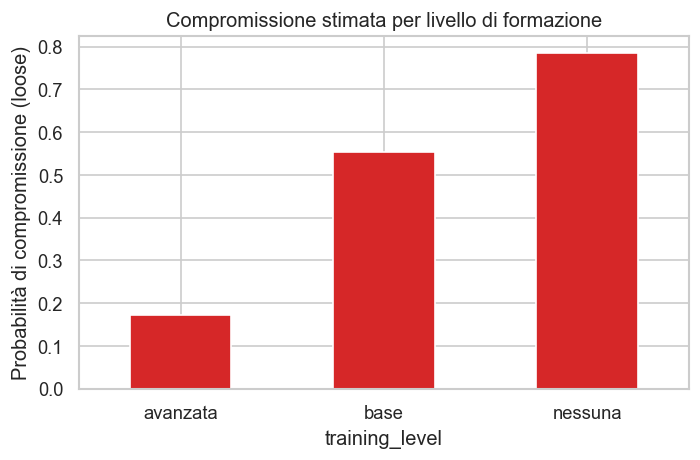

In [14]:
fig, ax = plt.subplots(figsize=(6,4))
comp_df["compromissione_loose"].plot(kind="bar", ax=ax, color="#d62728")
ax.set_ylabel("Probabilità di compromissione (loose)")
ax.set_title("Compromissione stimata per livello di formazione")
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "compromise_by_training.png")
fig.savefig(plot_path, dpi=300)
plot_path

In [15]:
crosstab_age = pd.crosstab(
    df["age_group"],
    df["choice"],
    normalize="index"
).round(3)

crosstab_age

choice,CHIEDI_AIUTO_AMICO,CLICCA_SUL_LINK,IGNORA,INSERISCI_CREDENZIALI,SEGNALA_COME_PHISHING
age_group,,,,,
15-20,0.000,0.812,0.083,0.000,0.104
21-25,0.000,0.479,0.090,0.000,0.431
26-30,0.000,0.660,0.104,0.000,0.236
31-45,0.029,0.450,0.121,0.017,0.383
46-60,0.000,0.667,0.083,0.000,0.250
60+,0.010,0.469,0.135,0.000,0.385


'results\\plots\\compromise_by_age_group.png'

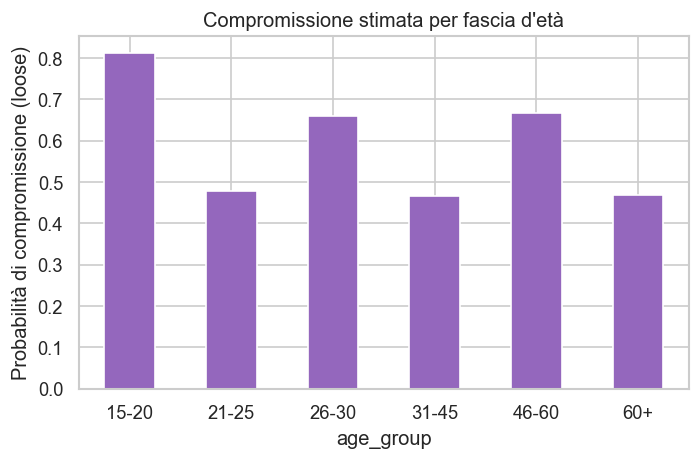

In [16]:
comp_by_age = df.groupby("age_group")["is_compromised_loose"].mean().round(3)

fig, ax = plt.subplots(figsize=(6,4))
comp_by_age.plot(kind="bar", ax=ax, color="#9467bd")
ax.set_ylabel("Probabilità di compromissione (loose)")
ax.set_title("Compromissione stimata per fascia d'età")
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "compromise_by_age_group.png")
fig.savefig(plot_path, dpi=300)
plot_path

In [17]:
comp_by_message = df.groupby("message_id")["is_compromised_loose"].mean().round(3)
comp_by_message

message_id
defi_airdrop_premio              0.644
discord_moderatore_rugpull       0.622
exchange_kyc_urgente             0.611
exchange_legit_password_reset    0.522
newsletter_legit_sicurezza       0.722
supporto_tecnico_seed            0.067
twitter_giveaway_match           0.267
update_app_store_falso           0.900
Name: is_compromised_loose, dtype: float64

'results\\plots\\compromise_by_message_id.png'

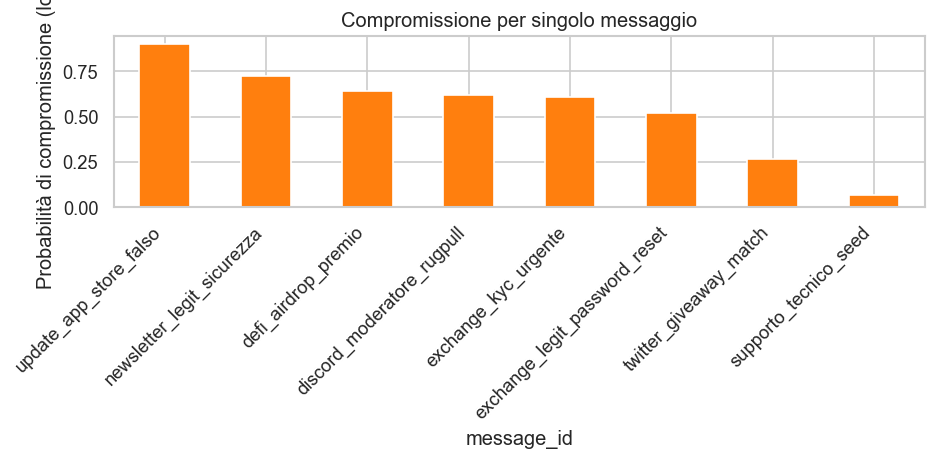

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
comp_by_message.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#ff7f0e")
ax.set_ylabel("Probabilità di compromissione (loose)")
ax.set_title("Compromissione per singolo messaggio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, "compromise_by_message_id.png")
fig.savefig(plot_path, dpi=300)
plot_path

In [19]:
crosstab_type.to_csv(os.path.join(PLOTS_DIR, "table_choices_by_message_type.csv"))
crosstab_train.to_csv(os.path.join(PLOTS_DIR, "table_choices_by_training.csv"))
crosstab_age.to_csv(os.path.join(PLOTS_DIR, "table_choices_by_age_group.csv"))
comp_df.to_csv(os.path.join(PLOTS_DIR, "table_compromise_by_training.csv"))
comp_by_message.to_csv(os.path.join(PLOTS_DIR, "table_compromise_by_message.csv"))